<a href="https://colab.research.google.com/github/kadamsoham760-lgtm/SYNTEXHUB_INTERNSHIP/blob/main/finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn openpyxl -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import files

In [10]:
# Upload the COVID-19 CSV file
uploaded = files.upload()

# Get the uploaded filename automatically
file_name = list(uploaded.keys())[0]

print("File uploaded successfully:", file_name)

Saving time_series_covid19_confirmed_global.csv to time_series_covid19_confirmed_global (1).csv
File uploaded successfully: time_series_covid19_confirmed_global (1).csv


In [11]:
# Read the dataset
df = pd.read_csv(file_name)

# Display basic information
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (289, 1147)

First 5 Rows:


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


In [12]:
# Identify date columns
date_columns = df.columns[4:]

# Convert date columns to numeric values
df[date_columns] = df[date_columns].apply(pd.to_numeric, errors='coerce')

# Group data by country and sum province/state values
country_data = df.groupby('Country/Region')[date_columns].sum()

# Transpose the data
country_data = country_data.T

# Convert index to datetime
country_data.index = pd.to_datetime(country_data.index)

# Sort by date
country_data = country_data.sort_index()

print("Prepared country-wise dataset:")
display(country_data.head())

Prepared country-wise dataset:


/tmp/ipykernel_3008/2316669743.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  country_data.index = pd.to_datetime(country_data.index)


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,2,0,0,0,0,0


In [13]:
# Calculate daily new cases
daily_cases = country_data.diff()

# Replace negative values caused by data corrections with zero
daily_cases = daily_cases.clip(lower=0)

# Remove the first row containing NaN values
daily_cases = daily_cases.fillna(0)

print("Daily cases calculated successfully.")

display(daily_cases.head())

Daily cases calculated successfully.


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
2020-01-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2020-01-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Countries to compare
selected_countries = [
    'India',
    'US',
    'Brazil',
    'United Kingdom'
]

# Check which selected countries exist in the dataset
available_countries = [
    country for country in selected_countries
    if country in country_data.columns
]

print("Available countries:", available_countries)

# Display missing countries
missing_countries = [
    country for country in selected_countries
    if country not in country_data.columns
]

if missing_countries:
    print("Countries not found:", missing_countries)

Available countries: ['India', 'US', 'Brazil', 'United Kingdom']


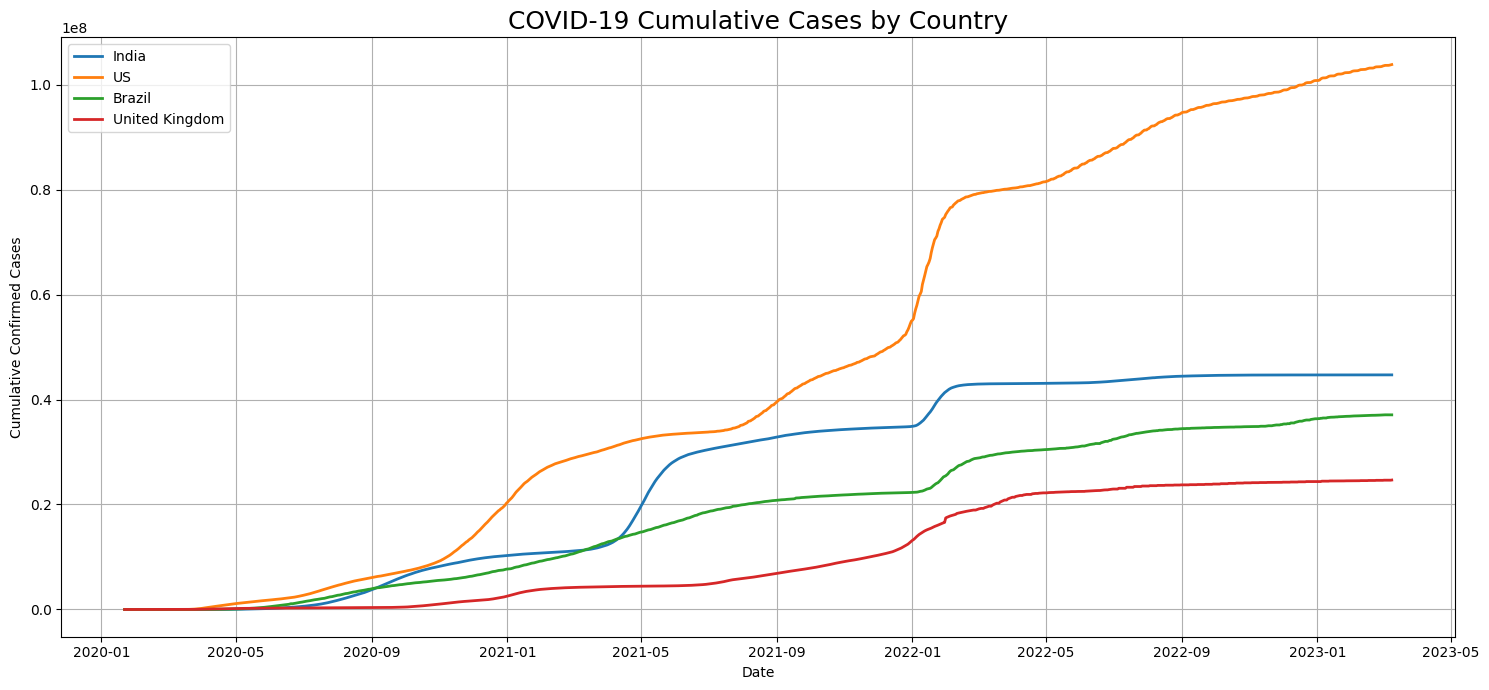

In [15]:
plt.figure(figsize=(15, 7))

for country in available_countries:
    plt.plot(
        country_data.index,
        country_data[country],
        label=country,
        linewidth=2
    )

plt.title("COVID-19 Cumulative Cases by Country", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("cumulative_cases_comparison.png", dpi=300)

plt.show()

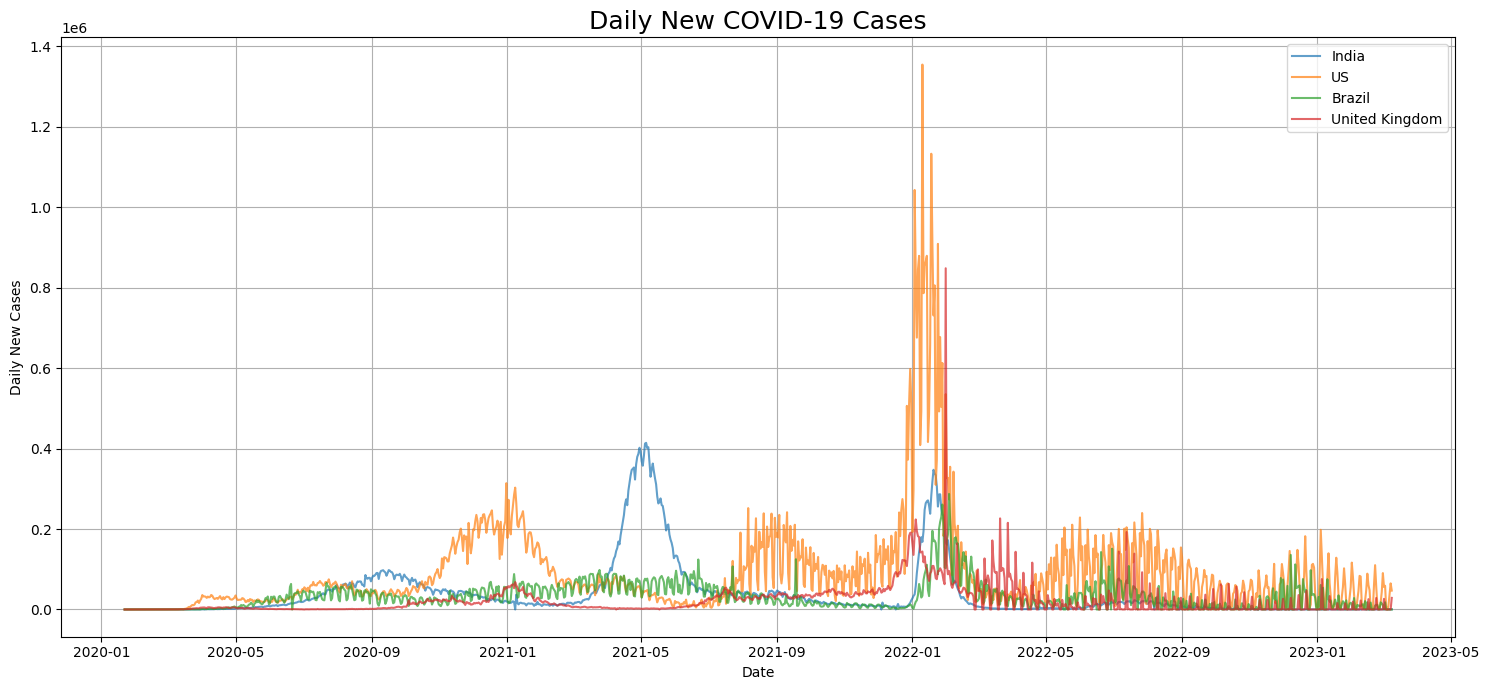

In [16]:
plt.figure(figsize=(15, 7))

for country in available_countries:
    plt.plot(
        daily_cases.index,
        daily_cases[country],
        label=country,
        alpha=0.7
    )

plt.title("Daily New COVID-19 Cases", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("daily_cases_comparison.png", dpi=300)

plt.show()

In [17]:
# Calculate 7-day rolling average
rolling_average = daily_cases.rolling(window=7).mean()

print("7-day rolling average calculated successfully.")

display(rolling_average.head(10))

7-day rolling average calculated successfully.


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
2020-01-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.714286,...,0.0,0.0,0.0,0.0,0.285714,0.0,0.0,0.0,0.0,0.0
2020-01-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.857143,...,0.0,0.0,0.0,0.0,0.285714,0.0,0.0,0.0,0.0,0.0
2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.285714,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2020-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.285714,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


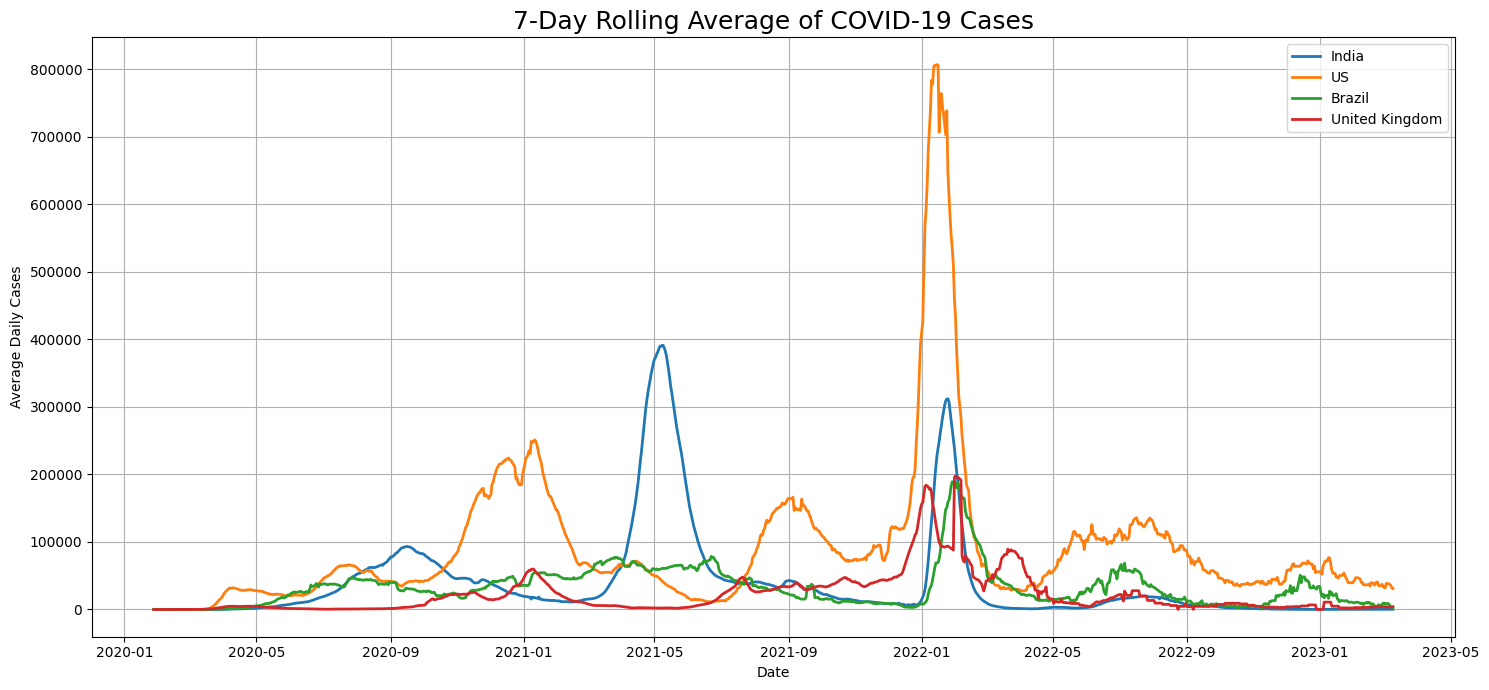

In [18]:
plt.figure(figsize=(15, 7))

for country in available_countries:
    plt.plot(
        rolling_average.index,
        rolling_average[country],
        label=country,
        linewidth=2
    )

plt.title("7-Day Rolling Average of COVID-19 Cases", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Average Daily Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("rolling_average_comparison.png", dpi=300)

plt.show()

In [19]:
peak_results = []

for country in available_countries:

    peak_date = daily_cases[country].idxmax()
    peak_cases = daily_cases[country].max()

    peak_results.append({
        "Country": country,
        "Peak Date": peak_date.date(),
        "Peak Daily Cases": int(peak_cases)
    })

peak_df = pd.DataFrame(peak_results)

print("COVID-19 Peak Analysis:")
display(peak_df)

COVID-19 Peak Analysis:


,Country,Peak Date,Peak Daily Cases
0,India,2021-05-06,414188
1,US,2022-01-10,1354505
2,Brazil,2022-02-03,287149
3,United Kingdom,2022-01-31,848169


In [20]:
rolling_peak_results = []

for country in available_countries:

    peak_date = rolling_average[country].idxmax()
    peak_value = rolling_average[country].max()

    rolling_peak_results.append({
        "Country": country,
        "Peak Date": peak_date.date(),
        "Peak 7-Day Average": round(peak_value, 2)
    })

rolling_peak_df = pd.DataFrame(rolling_peak_results)

print("Peak Based on 7-Day Rolling Average:")
display(rolling_peak_df)

Peak Based on 7-Day Rolling Average:


,Country,Peak Date,Peak 7-Day Average
0,India,2021-05-08,391232.00
1,US,2022-01-15,806962.86
2,Brazil,2022-01-29,189227.00
3,United Kingdom,2022-02-01,197997.57


In [21]:
# Resample daily cases into weekly totals
weekly_cases = daily_cases.resample('W').sum()

print("Weekly cases calculated successfully.")

display(weekly_cases.head())

Weekly cases calculated successfully.


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
2020-01-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2020-02-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
2020-02-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
2020-02-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
2020-02-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


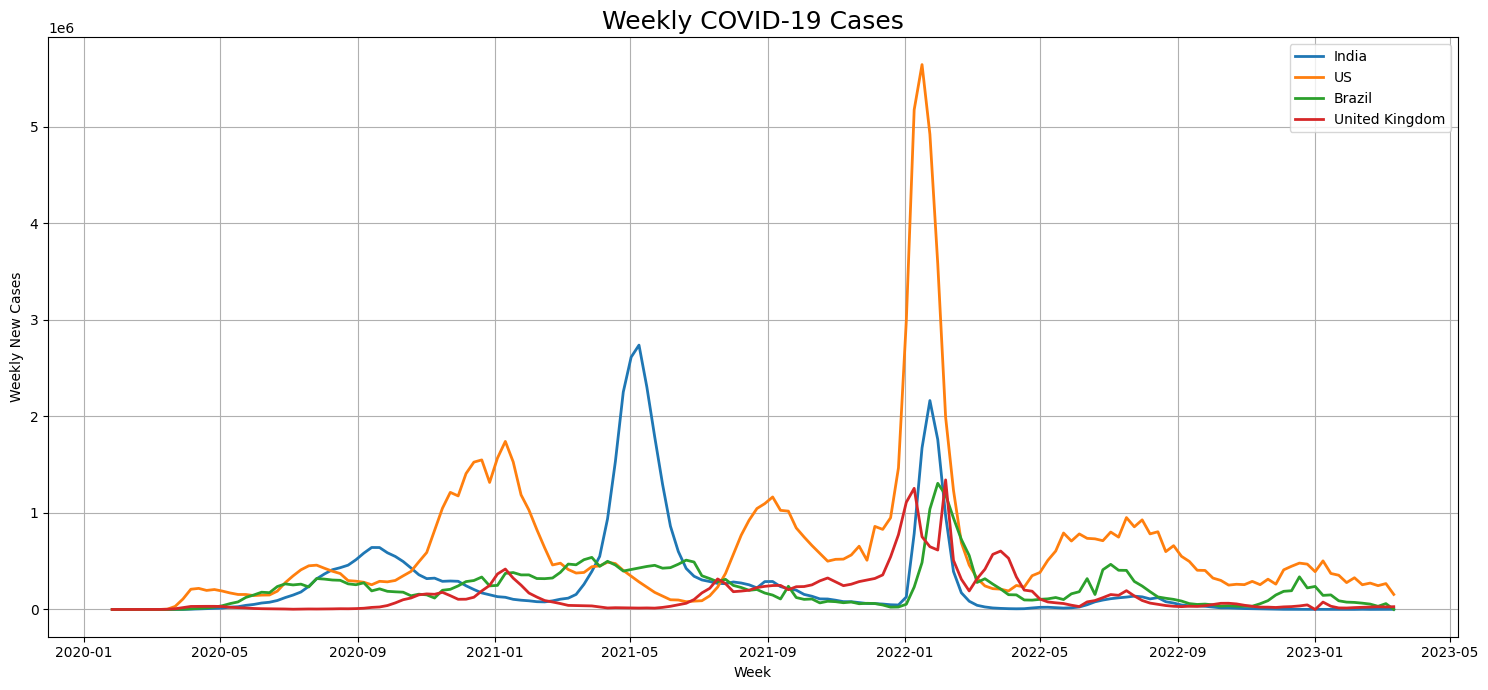

In [22]:
plt.figure(figsize=(15, 7))

for country in available_countries:
    plt.plot(
        weekly_cases.index,
        weekly_cases[country],
        label=country,
        linewidth=2
    )

plt.title("Weekly COVID-19 Cases", fontsize=18)
plt.xlabel("Week")
plt.ylabel("Weekly New Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("weekly_cases_comparison.png", dpi=300)

plt.show()

In [23]:
# Calculate growth ratio using 7-day rolling average
growth_ratio = rolling_average / rolling_average.shift(7)

# Get latest available growth ratio
latest_growth = growth_ratio.iloc[-1]

growth_results = []

for country in available_countries:

    value = latest_growth[country]

    if pd.isna(value):
        trend = "Insufficient Data"
    elif value > 1.10:
        trend = "Increasing"
    elif value < 0.90:
        trend = "Decreasing"
    else:
        trend = "Stable"

    growth_results.append({
        "Country": country,
        "Growth Ratio": round(value, 3),
        "Trend": trend
    })

growth_df = pd.DataFrame(growth_results)

print("Basic Reproduction / Growth Insight:")
display(growth_df)

Basic Reproduction / Growth Insight:


,Country,Growth Ratio,Trend
0,India,1.520,Increasing
1,US,0.967,Stable
2,Brazil,0.325,Decreasing
3,United Kingdom,1.091,Stable


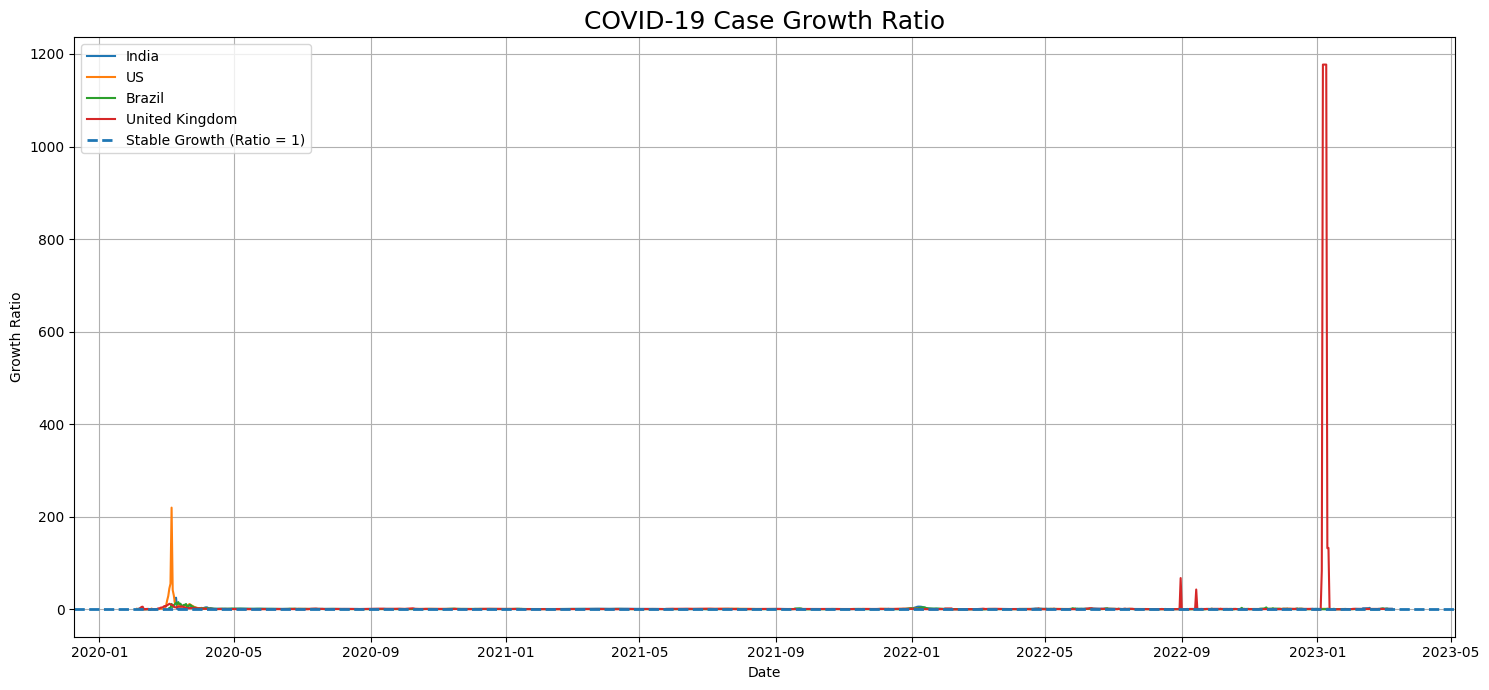

In [24]:
plt.figure(figsize=(15, 7))

for country in available_countries:
    plt.plot(
        growth_ratio.index,
        growth_ratio[country],
        label=country
    )

# Reference line
plt.axhline(
    y=1,
    linestyle='--',
    linewidth=2,
    label='Stable Growth (Ratio = 1)'
)

plt.title("COVID-19 Case Growth Ratio", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Growth Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("growth_ratio_comparison.png", dpi=300)

plt.show()

In [25]:
summary_results = []

for country in available_countries:

    total_cases = country_data[country].iloc[-1]

    max_daily_cases = daily_cases[country].max()

    peak_date = daily_cases[country].idxmax()

    avg_daily_cases = daily_cases[country].mean()

    latest_7day_average = rolling_average[country].iloc[-1]

    summary_results.append({
        "Country": country,
        "Total Confirmed Cases": int(total_cases),
        "Maximum Daily Cases": int(max_daily_cases),
        "Peak Date": peak_date.date(),
        "Average Daily Cases": round(avg_daily_cases, 2),
        "Latest 7-Day Average": round(latest_7day_average, 2)
    })

summary_df = pd.DataFrame(summary_results)

display(summary_df)

,Country,Total Confirmed Cases,Maximum Daily Cases,Peak Date,Average Daily Cases,Latest 7-Day Average
0,India,44690738,414188,2021-05-06,39102.28,335.71
1,US,103802702,1354505,2022-01-10,90819.39,30972.43
2,Brazil,37076053,287149,2022-02-03,32460.25,2535.00
3,United Kingdom,24658705,848169,2022-01-31,21583.24,4125.00


In [26]:
# Create an Excel file with multiple sheets
with pd.ExcelWriter("COVID19_Analysis_Results.xlsx", engine="openpyxl") as writer:

    country_data.to_excel(writer, sheet_name="Cumulative Cases")

    daily_cases.to_excel(writer, sheet_name="Daily Cases")

    weekly_cases.to_excel(writer, sheet_name="Weekly Cases")

    rolling_average.to_excel(writer, sheet_name="Rolling Average")

    peak_df.to_excel(writer, sheet_name="Daily Peaks", index=False)

    rolling_peak_df.to_excel(
        writer,
        sheet_name="Rolling Peaks",
        index=False
    )

    growth_df.to_excel(
        writer,
        sheet_name="Growth Analysis",
        index=False
    )

    summary_df.to_excel(
        writer,
        sheet_name="Final Summary",
        index=False
    )

print("Excel file created successfully.")

Excel file created successfully.


In [27]:
# List generated files
files_to_download = [
    "cumulative_cases_comparison.png",
    "daily_cases_comparison.png",
    "rolling_average_comparison.png",
    "weekly_cases_comparison.png",
    "growth_ratio_comparison.png",
    "COVID19_Analysis_Results.xlsx"
]

print("Generated files:")

for file in files_to_download:
    if os.path.exists(file):
        print("✓", file)

Generated files:
✓ cumulative_cases_comparison.png
✓ daily_cases_comparison.png
✓ rolling_average_comparison.png
✓ weekly_cases_comparison.png
✓ growth_ratio_comparison.png
✓ COVID19_Analysis_Results.xlsx
